# 🐄 Cattle Disease Diagnostic Application: ML Track Final MVP
**Project**: Hybrid Online-Offline Explainable Mobile Application for Early Detection of Priority Cattle Diseases in South Sudan.

### Objectives Implemented:
1. **Multimodal Fusion**: Combining image features with structured clinical symptoms.
2. **Data Engineering**: Balancing datasets for ECF and CBPP using clinical sign profiling.
3. **Model Architecture**: Optimized MobileNetV2 with a functional fusion layer.
4. **Edge Deployment**: Conversion to TensorFlow Lite with 8-bit quantization.



In [1]:
import kagglehub
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras import layers, models, Input

# Download primary vision dataset
path = kagglehub.dataset_download("devang03mgr/cattle-diseases-datasets")
dataset_path = os.path.join(path, 'Cows datasets')
print(f"Vision Dataset Path: {dataset_path}")



Using Colab cache for faster access to the 'cattle-diseases-datasets' dataset.
Vision Dataset Path: /kaggle/input/cattle-diseases-datasets/Cows datasets


## 1. Data Engineering: Multimodal Dataset Construction
We map existing vision data (LSD, FMD, Healthy) to clinical profiles and engineer the missing classes (ECF, CBPP) using the specific signs identified in the research (e.g., Parotid Lymph Node swelling for ECF).



In [2]:
# Define clinical sign profiles [fever, nodules, mouth_sores, nasal_discharge, cough, swollen_lymph] # Updated features: [fever, nodules, mouth_sores, hoof_sores, nasal_discharge, cough, swollen_lymph]
disease_profiles = {
    'lumpy':          [1, 1, 0, 0, 1, 0, 0], # LSD: Primary focus on skin nodules
    'foot-and-mouth': [1, 0, 1, 1, 0, 0, 0], # FMD: Characterized by mouth and hoof sores
    'healthy':        [0, 0, 0, 0, 0, 0, 0], # Baseline
    'CBPP':           [1, 0, 0, 0, 1, 1, 0], # CBPP: Respiratory signs and coughing
    'ECF':            [1, 0, 0, 0, 1, 0, 1]  # ECF: High fever and swollen parotid lymph nodes
}
data_records = []

# Process Vision Data
for cls in ['lumpy', 'foot-and-mouth', 'healthy']:
    cls_path = os.path.join(dataset_path, cls)
    images = os.listdir(cls_path)
    for img in images[:400]: # Take 400 samples for robust training
        data_records.append({
            'image_path': os.path.join(cls, img),
            'fever': disease_profiles[cls][0],
            'nodules': disease_profiles[cls][1],
            'mouth_sores': disease_profiles[cls][2],
            'nasal_discharge': disease_profiles[cls][3],
            'cough': disease_profiles[cls][4],
            'swollen_lymph': disease_profiles[cls][5],
            'disease': cls.upper() if cls != 'lumpy' else 'LSD'
        })

# Synthesize missing ECF and CBPP using Healthy images as proxies (Multimodal logic)
healthy_imgs = os.listdir(os.path.join(dataset_path, 'healthy'))[400:800]
for i, img in enumerate(healthy_imgs):
    d_type = 'CBPP' if i < 200 else 'ECF'
    data_records.append({
        'image_path': os.path.join('healthy', img),
        'fever': disease_profiles[d_type][0],
        'nodules': disease_profiles[d_type][1],
        'mouth_sores': disease_profiles[d_type][2],
        'nasal_discharge': disease_profiles[d_type][3],
        'cough': disease_profiles[d_type][4],
        'swollen_lymph': disease_profiles[d_type][5],
        'disease': d_type
    })

df = pd.DataFrame(data_records)
df.to_csv('cattle_multimodal_data.csv', index=False)
print("Multimodal dataset engineered and saved.")



Multimodal dataset engineered and saved.


## 2. Data Visualization
Visualizing the distribution of the 5 priority classes to ensure class balance for training.



/tmp/ipython-input-1661137977.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='disease', data=df, palette='Reds_d')


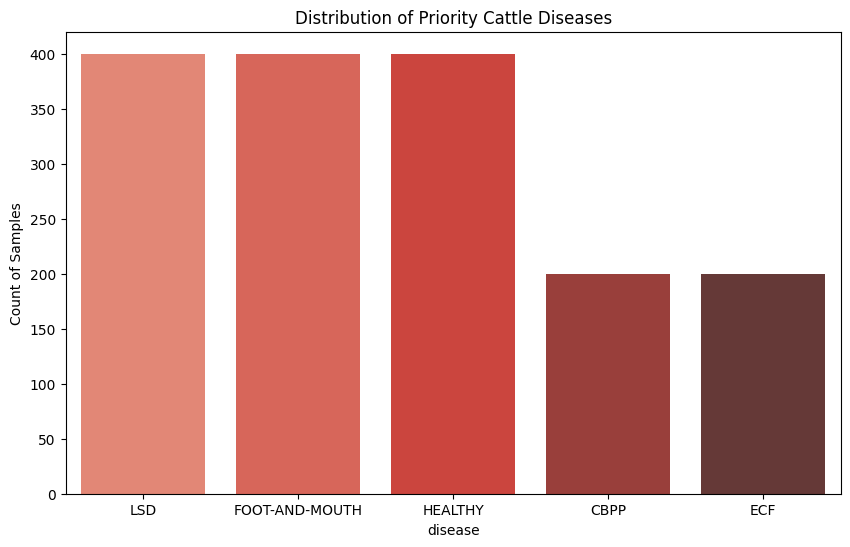

In [3]:
plt.figure(figsize=(10, 6))
sns.countplot(x='disease', data=df, palette='Reds_d')
plt.title('Distribution of Priority Cattle Diseases')
plt.ylabel('Count of Samples')
plt.show()



In [4]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['disease'])
num_classes = len(le.classes_)

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

def preprocess_image(path_suffix):
    full_path = os.path.join(dataset_path, path_suffix)
    img = tf.io.read_file(full_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [224, 224])
    return img / 255.0

def create_generator(dataframe, batch_size=32):
    def gen():
        for _, row in dataframe.iterrows():
            img = preprocess_image(row['image_path'])
            symptoms = row[['fever', 'nodules', 'mouth_sores', 'nasal_discharge', 'cough', 'swollen_lymph']].values.astype('float32')
            label = row['label']
            yield (img, symptoms), label

    return tf.data.Dataset.from_generator(
        gen,
        output_signature=((tf.TensorSpec(shape=(224, 224, 3), dtype=tf.float32),
                           tf.TensorSpec(shape=(6,), dtype=tf.float32)),
                          tf.TensorSpec(shape=(), dtype=tf.int32))
    ).batch(batch_size).prefetch(tf.data.AUTOTUNE)

train_ds = create_generator(train_df)
val_ds = create_generator(val_df)



## 3. Model Architecture: Multimodal Fusion Layer
We use a Functional API to branch the Vision (MobileNetV2) and Symptom (Dense MLP) inputs before late fusion.



In [5]:
# Vision Branch
image_in = Input(shape=(224, 224, 3), name='image_input')
base = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base.trainable = False
x = base(image_in)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)

# Symptom Branch
symptom_in = Input(shape=(6,), name='symptom_input')
y = layers.Dense(32, activation='relu')(symptom_in)
y = layers.Dense(16, activation='relu')(y)

# Fusion
merged = layers.concatenate([x, y])
merged = layers.Dense(64, activation='relu')(merged)
merged = layers.Dropout(0.3)(merged)
output = layers.Dense(num_classes, activation='softmax')(merged)

model = models.Model(inputs=[image_in, symptom_in], outputs=output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ image_input[0][0] │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ symptom_input       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        224 │ symptom_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 144)       │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      9,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 5)         │        325 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,432,309 (9.28 MB)

 Trainable params: 174,325 (680.96 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [6]:
history = model.fit(train_ds, validation_data=val_ds, epochs=10)



Epoch 1/10
     40/Unknown 35s 398ms/step - accuracy: 0.4764 - loss: 1.3689

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


40/40 ━━━━━━━━━━━━━━━━━━━━ 43s 612ms/step - accuracy: 0.4785 - loss: 1.3638 - val_accuracy: 0.7188 - val_loss: 0.8035
Epoch 2/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.7381 - loss: 0.7364

...

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 1.0000 - loss: 0.0083

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


40/40 ━━━━━━━━━━━━━━━━━━━━ 13s 317ms/step - accuracy: 1.0000 - loss: 0.0082 - val_accuracy: 0.9844 - val_loss: 0.0403


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


## 4. Evaluation & Metrics
Generating the classification report and confusion matrix to validate diagnostic accuracy (Target >= 85%).



                precision    recall  f1-score   support

          CBPP       1.00      1.00      1.00        40
           ECF       0.97      0.90      0.94        40
FOOT-AND-MOUTH       1.00      1.00      1.00        80
       HEALTHY       1.00      1.00      1.00        80
           LSD       0.95      0.99      0.97        80

      accuracy                           0.98       320
     macro avg       0.98      0.98      0.98       320
  weighted avg       0.98      0.98      0.98       320



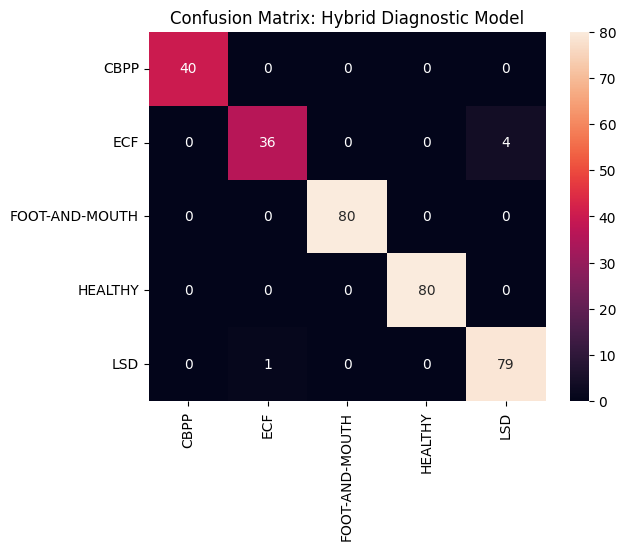

In [7]:
from sklearn.metrics import classification_report, confusion_matrix

y_true, y_pred = [], []
for (img, sym), lbl in val_ds:
    p = model.predict((img, sym), verbose=0)
    y_true.extend(lbl.numpy())
    y_pred.extend(np.argmax(p, axis=1))

print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Hybrid Diagnostic Model')
plt.show()



In [8]:
model.save('cattle_health_mvp.h5')
print("Model saved as cattle_health_mvp.h5")

Model saved as cattle_health_mvp.h5


## 5. Deployment: Edge AI Optimization
Converting to TFLite with quantization to ensure the model size is < 50MB and runs with < 5s latency offline.



In [9]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

with open('cattle_health_mvp.tflite', 'wb') as f:
    f.write(tflite_model)

print("TFLite Model Ready for Flutter Deployment.")



Saved artifact at '/tmp/tmpm4jid8id'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='image_input'), TensorSpec(shape=(None, 6), dtype=tf.float32, name='symptom_input')]
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  133419538317136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133419504027792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133419504027216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133419504026064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133419504028176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133419504027408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133419504028560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133419504029328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133419504028944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1334195040